In [1]:
# ── HR Analytics — Attrition & Salary Insights ────────────────
# What makes employees leave? What drives salary?
# Skills: read_csv, info, describe, isnull

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

np.random.seed(42)
n = 200

departments = np.random.choice(['Engineering','Analytics','Sales','HR','Finance'], n,
              p=[0.30,0.20,0.25,0.12,0.13])
experience = np.random.randint(1, 15, n)
gender     = np.random.choice(['M','F'], n, p=[0.55,0.45])
base_sal   = {'Engineering':95000,'Analytics':85000,'Sales':70000,
              'HR':62000,'Finance':78000}
salary = np.array([base_sal[d] + experience[i]*2200 +
                   np.random.randint(-8000,8000) for i,d in enumerate(departments)])
attrition = (np.random.random(n) < (0.35 - experience*0.02)).astype(int)
rating    = np.clip(np.random.normal(3.5, 0.7, n), 1, 5).round(1)

df = pd.DataFrame({
    'emp_id':     range(1001, 1001+n),
    'department': departments,
    'experience': experience,
    'gender':     gender,
    'salary':     salary,
    'performance_rating': rating,
    'attrition':  attrition
})
# Inject realistic messiness
df.loc[df.sample(12).index, 'salary'] = np.nan
df.loc[df.sample(8).index, 'performance_rating'] = np.nan

print(f"Dataset: {df.shape[0]} employees, {df.shape[1]} columns")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
df.head()

Dataset: 200 employees, 7 columns
Missing values:
salary                12
performance_rating     8
dtype: int64


,emp_id,department,experience,gender,salary,performance_rating,attrition
0,1001,Analytics,8,M,105928.0,2.9,1
1,1002,Finance,4,M,80993.0,4.0,0
2,1003,Sales,11,M,94615.0,3.8,0
3,1004,Sales,1,M,77750.0,4.4,0
4,1005,Engineering,8,F,119112.0,3.4,0


In [2]:
# ── Cell 2: Data Cleaning ──────────────────────────────────────
# Skills: fillna with group median, drop_duplicates, str ops, astype

# Fill salary NaN with department median (smarter than overall median)
df['salary'] = df.groupby('department')['salary'].transform(
    lambda x: x.fillna(x.median())
)

# Fill performance rating with overall median
df['performance_rating'].fillna(df['performance_rating'].median(), inplace=True)

# Add engineered columns
df['salary_band'] = pd.cut(df['salary'],
    bins=[0,70000,90000,110000,999999],
    labels=['Junior','Mid','Senior','Lead'])

df['experience_group'] = pd.cut(df['experience'],
    bins=[0,3,7,15],
    labels=['0-3 yrs','4-7 yrs','8+ yrs'])

df['attrition_label'] = df['attrition'].map({0:'Stayed', 1:'Left'})

print("After cleaning:")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Attrition rate: {df['attrition'].mean()*100:.1f}%")
df[['department','salary','salary_band','experience_group']].head()

After cleaning:
Missing values: 0
Attrition rate: 18.5%


,department,salary,salary_band,experience_group
0,Analytics,105928.0,Senior,8+ yrs
1,Finance,80993.0,Mid,4-7 yrs
2,Sales,94615.0,Senior,8+ yrs
3,Sales,77750.0,Mid,0-3 yrs
4,Engineering,119112.0,Lead,8+ yrs


In [3]:
# ── Cell 3: merge() — join dept metadata ──────────────────────
# Skill: pd.merge — like VLOOKUP / SQL JOIN

dept_info = pd.DataFrame({
    'department':   ['Engineering','Analytics','Sales','HR','Finance'],
    'dept_head':    ['Sundar K','Meena R','Vikram P','Deepa S','Arun T'],
    'dept_budget_cr':[45.2,28.5,35.0,12.4,22.1],
    'location':     ['Bengaluru','Bengaluru','Mumbai','Pune','Hyderabad']
})

df_merged = pd.merge(df, dept_info, on='department', how='left')

print(f"Before merge: {df.shape[1]} columns")
print(f"After merge:  {df_merged.shape[1]} columns (added dept_head, budget, location)")
df_merged[['emp_id','department','dept_head','location','salary']].head()

Before merge: 10 columns
After merge:  13 columns (added dept_head, budget, location)


,emp_id,department,dept_head,location,salary
0,1001,Analytics,Meena R,Bengaluru,105928.0
1,1002,Finance,Arun T,Hyderabad,80993.0
2,1003,Sales,Vikram P,Mumbai,94615.0
3,1004,Sales,Vikram P,Mumbai,77750.0
4,1005,Engineering,Sundar K,Bengaluru,119112.0


In [4]:
# ── Cell 4: pivot_table() — the power move ─────────────────────
# Skill: pivot_table with multiple aggfuncs, margins

# Q1: Avg salary by department + gender
salary_pivot = df_merged.pivot_table(
    values='salary',
    index='department',
    columns='gender',
    aggfunc='mean',
    margins=True,
    margins_name='Overall'
).round(0)
print("=== AVG SALARY BY DEPT + GENDER ===")
print(salary_pivot)

# Q2: Attrition rate by dept + experience group
attrition_pivot = df_merged.pivot_table(
    values='attrition',
    index='department',
    columns='experience_group',
    aggfunc='mean'
).round(2) * 100
print("\n=== ATTRITION RATE (%) BY DEPT + EXPERIENCE ===")
print(attrition_pivot)

=== AVG SALARY BY DEPT + GENDER ===
gender              F         M   Overall
department                               
Analytics    100863.0   99814.0  100193.0
Engineering  112999.0  109917.0  111505.0
Finance       92077.0   98298.0   95187.0
HR            75107.0   77897.0   76805.0
Sales         86489.0   86567.0   86524.0
Overall       97572.0   97093.0   97323.0

=== ATTRITION RATE (%) BY DEPT + EXPERIENCE ===
experience_group  0-3 yrs  4-7 yrs  8+ yrs
department                                
Analytics             0.0     33.0    21.0
Engineering          24.0     12.0    15.0
Finance               0.0     12.0    29.0
HR                   22.0     33.0     0.0
Sales                20.0     27.0    18.0


In [5]:
# ── Cell 5: str ops + business questions ──────────────────────

# Who are the high performers being underpaid?
df_merged['dept_short'] = df_merged['department'].str[:3].str.upper()

at_risk = df_merged[
    (df_merged['performance_rating'] >= 4.0) &
    (df_merged['attrition'] == 1)
][['emp_id','department','salary','performance_rating','experience']]
print(f"High performers who left: {len(at_risk)}")
print(at_risk.sort_values('performance_rating', ascending=False).head(8))

# Department summary — one chain
dept_summary = (df_merged
    .groupby('department')
    .agg(
        headcount    = ('emp_id',     'count'),
        avg_salary   = ('salary',     'mean'),
        attrition_pct= ('attrition',  'mean'),
        avg_rating   = ('performance_rating', 'mean')
    )
    .round(2)
    .sort_values('attrition_pct', ascending=False)
)
dept_summary['attrition_pct'] = (dept_summary['attrition_pct']*100).round(1)
print("\n=== DEPARTMENT SUMMARY ===")
print(dept_summary)

High performers who left: 7
     emp_id   department    salary  performance_rating  experience
190    1191  Engineering  122367.0                 5.0          10
145    1146  Engineering  112831.0                 4.4           9
78     1079    Analytics   97414.0                 4.3           8
96     1097        Sales   90941.0                 4.3          10
91     1092        Sales   75481.0                 4.2           3
90     1091  Engineering  102251.0                 4.1           1
9      1010        Sales  106328.0                 4.0          14

=== DEPARTMENT SUMMARY ===
             headcount  avg_salary  attrition_pct  avg_rating
department                                                   
Analytics           36   100192.64           22.0        3.58
Sales               47    86523.57           21.0        3.44
Finance             28    95187.21           18.0        3.62
Engineering         66   111504.59           17.0        3.67
HR                  23    76805.22  

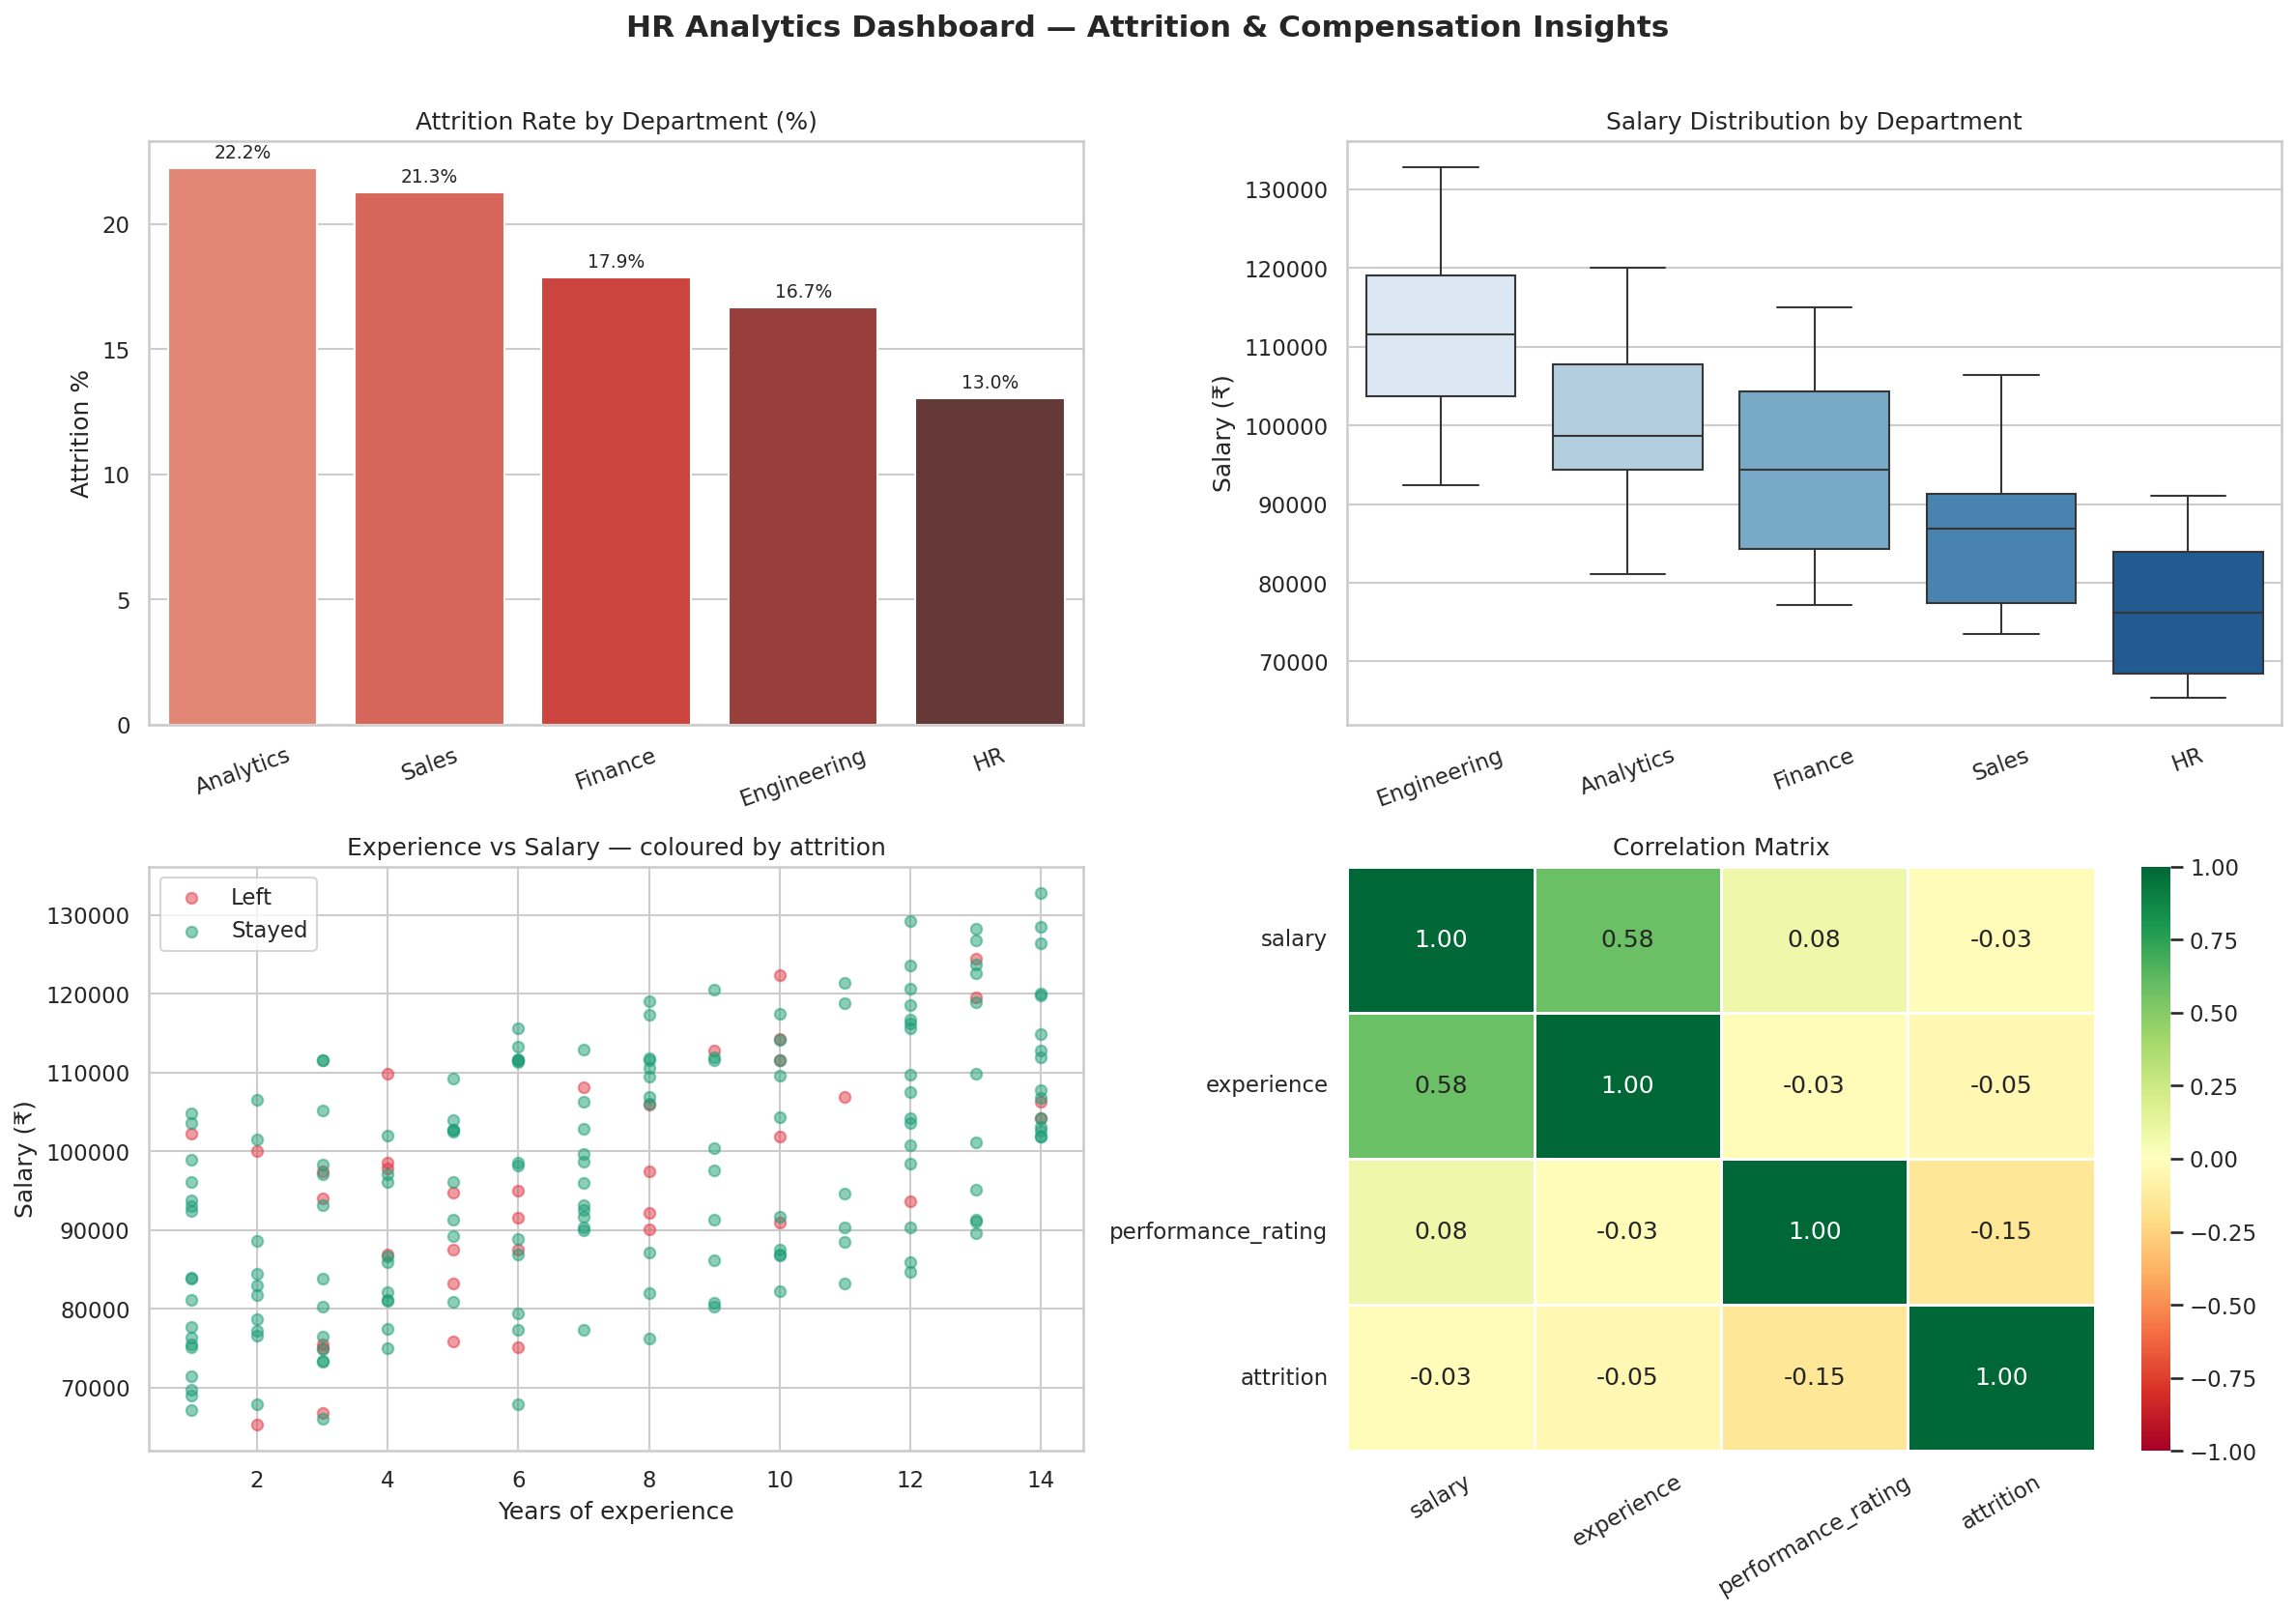

Dashboard saved!


In [6]:
# ── Cell 6: Visualisation dashboard ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('HR Analytics Dashboard — Attrition & Compensation Insights',
             fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Attrition by department (bar)
attr_dept = df_merged.groupby('department')['attrition'].mean().sort_values(ascending=False)*100
sns.barplot(x=attr_dept.index, y=attr_dept.values, palette='Reds_d', ax=axes[0,0])
axes[0,0].set_title('Attrition Rate by Department (%)')
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('Attrition %')
axes[0,0].tick_params(axis='x', rotation=20)
for p in axes[0,0].patches:
    axes[0,0].annotate(f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()+0.4), ha='center', fontsize=9)

# Plot 2: Salary distribution by dept (box)
dept_order = df_merged.groupby('department')['salary'].median().sort_values(ascending=False).index
sns.boxplot(data=df_merged, x='department', y='salary',
            order=dept_order, palette='Blues', ax=axes[0,1])
axes[0,1].set_title('Salary Distribution by Department')
axes[0,1].set_xlabel(''); axes[0,1].set_ylabel('Salary (₹)')
axes[0,1].tick_params(axis='x', rotation=20)

# Plot 3: Attrition vs experience (scatter with hue)
colors = {'Stayed':'#1D9E75', 'Left':'#e23744'}
for label, grp in df_merged.groupby('attrition_label'):
    axes[1,0].scatter(grp['experience'], grp['salary'],
                     label=label, alpha=0.5, color=colors[label], s=30)
axes[1,0].set_title('Experience vs Salary — coloured by attrition')
axes[1,0].set_xlabel('Years of experience'); axes[1,0].set_ylabel('Salary (₹)')
axes[1,0].legend()

# Plot 4: Correlation heatmap
num_cols = ['salary','experience','performance_rating','attrition']
sns.heatmap(df_merged[num_cols].corr().round(2),
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('hr_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [7]:
# ── Cell 7: Download everything ───────────────────────────────
from google.colab import files

dept_summary.to_csv('dept_summary.csv')
df_merged.to_csv('hr_data_clean.csv', index=False)

for f in ['hr_dashboard.png', 'dept_summary.csv']:
    files.download(f)

print("Downloaded: hr_dashboard.png + dept_summary.csv")
print("Post the dashboard image on LinkedIn!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: hr_dashboard.png + dept_summary.csv
Post the dashboard image on LinkedIn!
